# Empirical Analysis: Super-Hedging with Transaction Costs (SPY)

## Overview

This notebook implements an **empirical study on model-free super-hedging of European call options under proportional transaction costs**.

**Research Focus:**
- **Method:** Model-free approach using support bands calibrated from historical returns
- **Asset:** ETF SPY (Standard & Poor's 500)
- **Period:** January 1, 2020 – February 23, 2026
- **Analysis:** Partition into successive 21-day trading periods with rolling 252-day calibration windows

**Authors:** Emmanuel Lepinette & Amal Omrani  
**Institution:** CEREMADE, UMR CNRS 7534, Paris-Dauphine University, PSL  
**Year:** 2026

### Study Design

#### Data & Methodology
- **Asset**: ETF SPY (Standard & Poor's 500)
- **Period**: January 1, 2020 – February 23, 2026
- **Analysis**: Partition into successive 21-day trading periods
- **Calibration**: Rolling 252-day window for support band parameters
- **Payoff**: At-the-Money (ATM) European call options

#### Transaction Cost Rates Tested
- $\kappa = 0$ (frictionless benchmark)
- $\kappa = 5 \times 10^{-4}$
- $\kappa = 10^{-3}$
- $\kappa = 5 \times 10^{-3}$
- $\kappa = 9 \times 10^{-3}$ (extended analysis)

#### Key Metrics Computed
- **RSE** ($\epsilon^j$): Relative Super-hedging Error = $(V_T^j - \text{payoff}) / S_T^j$
- **Pj** ($P^j(\kappa)$): Normalized initial price = $V_0^j / S_0^j$
- **I** ($I^j(\kappa)$): Cost Impact = $(P^j(\kappa) - P^j(0)) / \kappa$

### Helper Functions

Data-loading and plotting utilities are in `def_plots.py`:
- `load_and_metrics()`: Load simulation results with kappa labels
- `compute_I()`: Compute cost impact
- `plot_rse()`, `plot_pj_logscale()`, `plot_impact_cost()`: Visualization helpers

---

## Table of Contents

1. **Setup & Data Loading** – Import libraries and load simulation results
2. **Distribution Analysis** – RSE, Normalized Prices, Cost Impact distributions
3. **Time-Series Data Preparation** – Download SPY data and construct support bands
4. **Time-Series Overlay** – SPY prices, support bands, and normalized prices evolution
5. **Grid Study** – Detailed cost impact analysis over continuous κ range
6. **Summary & Key Findings** – Final statistics and insights

## 1. Setup & Data Loading

Import required libraries and load simulation results from CSV files.

In [16]:
# -----------------------------
# 1. Import Required Libraries
# -----------------------------
import os
import importlib
import numpy as np
import pandas as pd
import def_plots as dp
import matplotlib.pyplot as plt
import yfinance as yf
import seaborn as sns
from sklearn.metrics import r2_score
importlib.reload(dp)

<module 'def_plots' from '/Users/omrani/Desktop/A2Amal-29042026/GithubEmpericalStudy/def_plots.py'>

In [17]:
# -----------------------------
# 2. Load Simulation Results and Set Up Labels
# -----------------------------
# Load results for each kappa value and concatenate into a single DataFrame
d0    = dp.load_and_metrics("results_kappa_0.csv",      r"$\kappa=0$")
d0005 = dp.load_and_metrics("results_kappa_0.0005.csv", r"$\kappa=5\times10^{-4}$")
d001  = dp.load_and_metrics("results_kappa_0.001.csv",  r"$\kappa=10^{-3}$")
d005 = dp.load_and_metrics("results_kappa_0.005.csv",  r"$\kappa=5\times10^{-3}$")
d009 = dp.load_and_metrics("results_kappa_0.009.csv",  r"$\kappa=9\times10^{-3}$")
#d01   = dp.load_and_metrics("results_kappa_0.01.csv",   r"$\kappa=10^{-2}$")

allm = pd.concat([d0, d0005, d001, d005, d009], ignore_index=True)
# Define the exact labels for each kappa value (used for plotting and grouping)
label_0 = r"$\kappa=0$"
label_0005 = r"$\kappa=5\times10^{-4}$"
label_001 = r"$\kappa=10^{-3}$"
label_005 = r"$\kappa=5\times10^{-3}$"
label_009 = r"$\kappa=9\times10^{-3}$"
#label_01 = r"$\kappa=10^{-2}$"

## 2. Distribution Analysis – Key Metrics Across All Periods

This section visualizes the empirical distributions of three main quantities:
- **RSE** ($\epsilon^j$): Relative super-hedging error
- **Pj** ($P^j(\kappa)$): Normalized initial super-hedging price  
- **Cost Impact** ($I^j(\kappa)$): Marginal impact of transaction costs

Each metric is shown as both a histogram and boxplot for different $\kappa$ values.

### 2.1 Relative Super-Hedging Error ($\epsilon^j$)

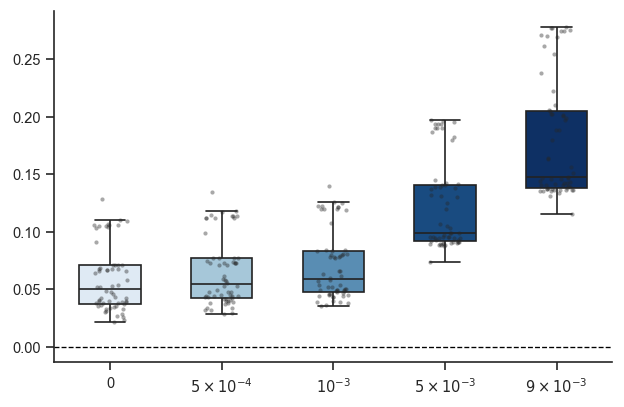

In [18]:
# -----------------------------
# 3. Visualize Relative Super-Hedging Error (RSE)
# -----------------------------
# Boxplot of RSE for each kappa value
# yb, yt = dp.auto_broken_limits(allm, ycol="RSE", main_q=0.98, outlier_q=0.995, pad=0.005)
dp.plot_rse(
    allm,
    ycol="RSE",
    savepath="Fig_RSE.pdf"
)

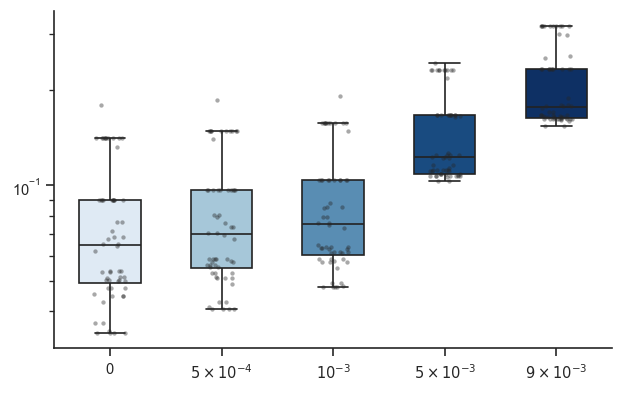

In [19]:
# -----------------------------
# 4. Visualize Normalized Price (Pj) on Log Scale
# -----------------------------
# Boxplot of normalized price (Pj) for each kappa value (log scale)
dp.plot_pj_logscale(
    allm,
    ycol="Pj",
    savepath="Fig_Pj_logscale.pdf"
)

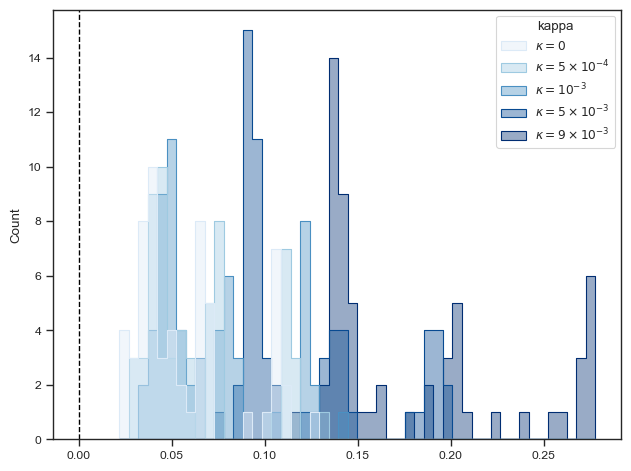

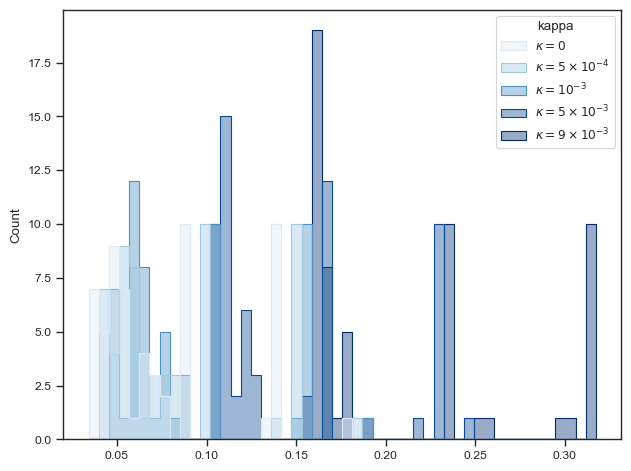

In [20]:
# -----------------------------
# 5. Histograms: RSE and Normalized Price by Kappa
# -----------------------------
# Plot histograms of RSE and Pj for each kappa value (color-coded)
order = [r"$\kappa=0$", r"$\kappa=5\times10^{-4}$", r"$\kappa=10^{-3}$", r"$\kappa=5\times10^{-3}$", r"$\kappa=9\times10^{-3}$"]
palette = {
    order[0]: "#DCEAF7",
    order[1]: "#9ECAE1",
    order[2]: "#4A90C2",
    order[3]: "#084A91",
    order[4]: "#002D72"
}

plot_data = allm.copy()
plot_data["kappa"] = pd.Categorical(plot_data["kappa"], categories=order, ordered=True)

rse_data = plot_data[np.isfinite(plot_data["RSE"])]
pj_data  = plot_data[np.isfinite(plot_data["Pj"])]

# Histogram of relative super-hedging error (RSE)
fig, ax = plt.subplots()
sns.histplot(
    data=rse_data, x="RSE", hue="kappa", hue_order=order,
    palette=palette, common_norm=False, 
    alpha=0.4, element="step", bins=50, ax=ax
)
ax.axvline(0, color="black", ls="--", lw=1.0)
ax.set_xlabel("")
ax.set_ylabel("Count")
plt.tight_layout()
plt.savefig("fig_rse_hist.pdf", bbox_inches="tight")
plt.savefig("fig_rse_hist.png", bbox_inches="tight")
plt.show()

# Histogram of normalized price (Pj)
fig, ax = plt.subplots()
sns.histplot(
    data=pj_data, x="Pj", hue="kappa", hue_order=order,
    palette=palette, common_norm=False, 
    alpha=0.4, element="step", bins=50, ax=ax
)
ax.set_xlabel("")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

### 2.2 Normalized Super-Hedging Price ($P^j(\kappa)$)

The normalized price increases monotonically as transaction costs rise, indicating higher initial capital requirements for super-replication.

In [21]:
# -----------------------------
# 6. Summary Table: Normalized Prices by Kappa
# -----------------------------
# Generate and display summary statistics for normalized prices (Pj) by kappa
stat_table_NP= allm.groupby('kappa')['Pj'].describe()

# Define the exact order from smallest to highest kappa
kappa_order = [
    r"$\kappa=0$", 
    r"$\kappa=5\times10^{-4}$", 
    r"$\kappa=10^{-3}$", 
    r"$\kappa=5\times10^{-3}$",
    r"$\kappa=9\times10^{-3}$"
]
# Force the table to use this exact row order
stat_table_NP = stat_table_NP.reindex(kappa_order)

# Display the nicely formatted table
display(stat_table_NP.round(4))

,count,mean,std,min,25%,50%,75%,max
kappa,,,,,,,,
$\kappa=0$,60.0,0.0764,0.0380,0.0342,0.0492,0.0647,0.0900,0.1797
$\kappa=5\times10^{-4}$,60.0,0.0828,0.0388,0.0408,0.0548,0.0700,0.0969,0.1857
$\kappa=10^{-3}$,60.0,0.0894,0.0396,0.0478,0.0605,0.0755,0.1040,0.1919
$\kappa=5\times10^{-3}$,60.0,0.1472,0.0477,0.1029,0.1087,0.1226,0.1662,0.2438
$\kappa=9\times10^{-3}$,60.0,0.2100,0.0598,0.1541,0.1625,0.1765,0.2332,0.3172


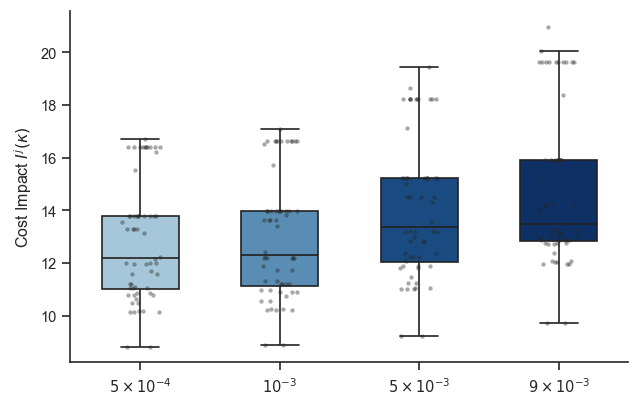

In [22]:
# -----------------------------
# 7. Compute and Visualize Cost Impact (I)
# -----------------------------
# Compute the cost impact (I) for each row and plot the result
df_impact = dp.compute_I(allm, pj_col="Pj", kappa_col="kappa", id_col="i")

# Visualize cost impact
dp.plot_impact_cost(df_impact, ycol="I", savepath="Fig_Impact_Cost.pdf")

In [23]:
# -----------------------------
# 8. Summary Table: Cost Impact by Kappa
# -----------------------------
# Generate and display summary statistics for cost impact (I) by kappa
stat_table_CI = df_impact.groupby('kappa')['I'].describe()

# Define the exact order from smallest to highest kappa
kappa_order_CI = [ 
    r"$\kappa=5\times10^{-4}$", 
    r"$\kappa=10^{-3}$", 
    r"$\kappa=5\times10^{-3}$",
    r"$\kappa=9\times10^{-3}$"
]
# Force the table to use this exact row order
stat_table_CI = stat_table_CI.reindex(kappa_order_CI)

# Display the nicely formatted table
display(stat_table_CI.round(4))

,count,mean,std,min,25%,50%,75%,max
kappa,,,,,,,,
$\kappa=5\times10^{-4}$,60.0,12.8466,2.2711,8.8347,11.0179,12.1911,13.8035,16.7241
$\kappa=10^{-3}$,60.0,13.0257,2.3241,8.8871,11.1461,12.3263,13.9889,17.1049
$\kappa=5\times10^{-3}$,60.0,14.1481,2.6591,9.2385,12.0402,13.3838,15.2378,19.4457
$\kappa=9\times10^{-3}$,60.0,14.8382,2.9299,9.7285,12.8580,13.4861,15.9097,20.9534


In [24]:
# -----------------------------
# 9. Summary Table: Relative Super-Hedging Error (RSE) by Kappa
# -----------------------------
# Generate and display summary statistics for RSE by kappa
stat_table_RSE = allm.groupby('kappa')['RSE'].describe()
# Force the table to use this exact row order
stat_table_RSE = stat_table_RSE.reindex(kappa_order)

# Display the nicely formatted table
display(stat_table_RSE.round(4))

,count,mean,std,min,25%,50%,75%,max
kappa,,,,,,,,
$\kappa=0$,60.0,0.0585,0.0280,0.0217,0.0372,0.0500,0.0706,0.1287
$\kappa=5\times10^{-4}$,60.0,0.0643,0.0289,0.0283,0.0423,0.0540,0.0767,0.1342
$\kappa=10^{-3}$,60.0,0.0702,0.0298,0.0351,0.0472,0.0584,0.0831,0.1398
$\kappa=5\times10^{-3}$,60.0,0.1225,0.0390,0.0733,0.0914,0.0990,0.1407,0.1966
$\kappa=9\times10^{-3}$,60.0,0.1793,0.0517,0.1152,0.1383,0.1473,0.2048,0.2777


---

## 3. Time-Series Data Preparation: SPY Download & Support Bands

Download historical SPY price data and construct rolling calibration windows for support band analysis.

### 3.1 Download SPY Prices and Compute Returns

In [25]:
# -----------------------------
# 11. Download and Prepare SPY Data for Support Bands
# -----------------------------
# Download SPY price data and construct rolling calibration windows for support band analysis.
ticker = "SPY"
start_date = "2020-01-01"
end_date   = "2026-02-23"

calibration_window = 252   # 1 year = 252 trading days
period_length = 21         # N = 21 days
T = 20                     # horizon (0,...,20)

# Download daily price data
data = yf.download(ticker, start=start_date, end=end_date)

close = data["Close"]
if isinstance(close, pd.DataFrame):
    close = close.iloc[:, 0]
close = close.dropna()

# Compute daily returns
returns = (close / close.shift(1)).dropna()

# Build periods: split timeline into blocks of 21 trading days
num_periods = (len(close) - calibration_window) // period_length

results = []

for j in range(num_periods):
    # Define period j
    start_idx = calibration_window + j * period_length
    end_idx   = start_idx + period_length
    if end_idx >= len(close):
        break
    # Prices for period j
    S_window = close.iloc[start_idx:end_idx].values
    S0 = S_window[0]
    ST = S_window[-1]
    # Calibration window (past 252 days)
    ret_window = returns.iloc[start_idx - calibration_window : start_idx]
    # α^j and β^j (extreme returns)
    alpha_j = ret_window.min()
    beta_j  = ret_window.max()
    # Constant coefficients over time
    alpha_list = [float(alpha_j)] * T
    beta_list  = [float(beta_j)] * T
    # ATM strike
    K_j = S0
    # Store results
    results.append({
        "period": j,
        "S0": S0,
        "ST": ST,
        "alpha": alpha_j,
        "beta": beta_j,
        "K": K_j
    })

# Convert to DataFrame and display summary
results_df = pd.DataFrame(results)
print(results_df.head())
print("number of periods:", num_periods)

[*********************100%***********************]  1 of 1 completed

   period          S0          ST     alpha      beta           K
0       0  348.057587  350.245331  0.890576  1.090603  348.057587
1       1  355.197784  355.076813  0.890576  1.090603  355.197784
2       2  350.682800  374.162903  0.890576  1.090603  350.682800
3       3  379.533295  390.591675  0.942351  1.067166  379.533295
4       4  388.182037  392.580994  0.942351  1.030460  388.182037
number of periods: 61




The figure provides a comprehensive view of:
- **SPY price path** (dark line): Historical ETF prices from Jan 2020 to Feb 2026
- **Support bands** (orange/purple dashed): Dynamically calibrated from rolling 252-day windows
- **Normalized prices $P^j(\kappa)$** (blue shades): Evolution of super-hedging prices for all $\kappa$ values

**Key observations:**
- SPY remains strictly within support bands 
- Bands widen during high-volatility periods (2020–2021, 2025–2026)
- $P^j$ curves shift upward as $\kappa$ increases, reflecting higher transaction cost impacts
- Support band width correlates with $P^j(\kappa)$ levels, demonstrating price sensitivity to market uncertainty

### 3.2 Construct Support Bands from Rolling Windows

In [26]:
# -----------------------------
# Construct and Plot Support Bands for SPY
# -----------------------------
# Compute lower and upper support bands for each period and define a plotting function.
alphas = []
betas = []
period_starts = []

for j in range(num_periods):
    start_idx = calibration_window + j * period_length
    end_idx   = start_idx + period_length
    if end_idx >= len(close):
        break
    ret_window = returns.iloc[start_idx - calibration_window : start_idx]
    alphas.append(ret_window.min())
    betas.append(ret_window.max())
    period_starts.append(start_idx)

lower_full = pd.Series(index=close.index, dtype=float)
upper_full = pd.Series(index=close.index, dtype=float)

for j in range(len(period_starts)):
    start_idx = period_starts[j]
    end_idx = start_idx + period_length
    if end_idx > len(close):
        break
    S_segment = close.iloc[start_idx:end_idx]
    alpha_j = alphas[j]
    beta_j  = betas[j]
    S_vals = S_segment.values
    lower_full.iloc[start_idx+1:end_idx] = alpha_j * S_vals[:-1]
    upper_full.iloc[start_idx+1:end_idx] = beta_j * S_vals[:-1]

def plot_full_support(close, lower_full, upper_full):
    plt.figure(figsize=(14, 6))
    # Price
    plt.plot(close.index, close.values, color="black", linewidth=1.5, label="SPY")
    # Lower bound (orange)
    plt.plot(close.index, lower_full.values, color="#E67E22", linewidth=1.2, linestyle="--", label="Lower bound")
    # Upper bound (violet)
    plt.plot(close.index, upper_full.values, color="#8E44AD", linewidth=1.2, linestyle="--", label="Upper bound")
    # Shaded region
    plt.fill_between(close.index, lower_full.values, upper_full.values, color="gray", alpha=0.15)
    #plt.title("SPY Price with Piecewise Calibrated Support Bands")
    plt.legend()
    plt.show()

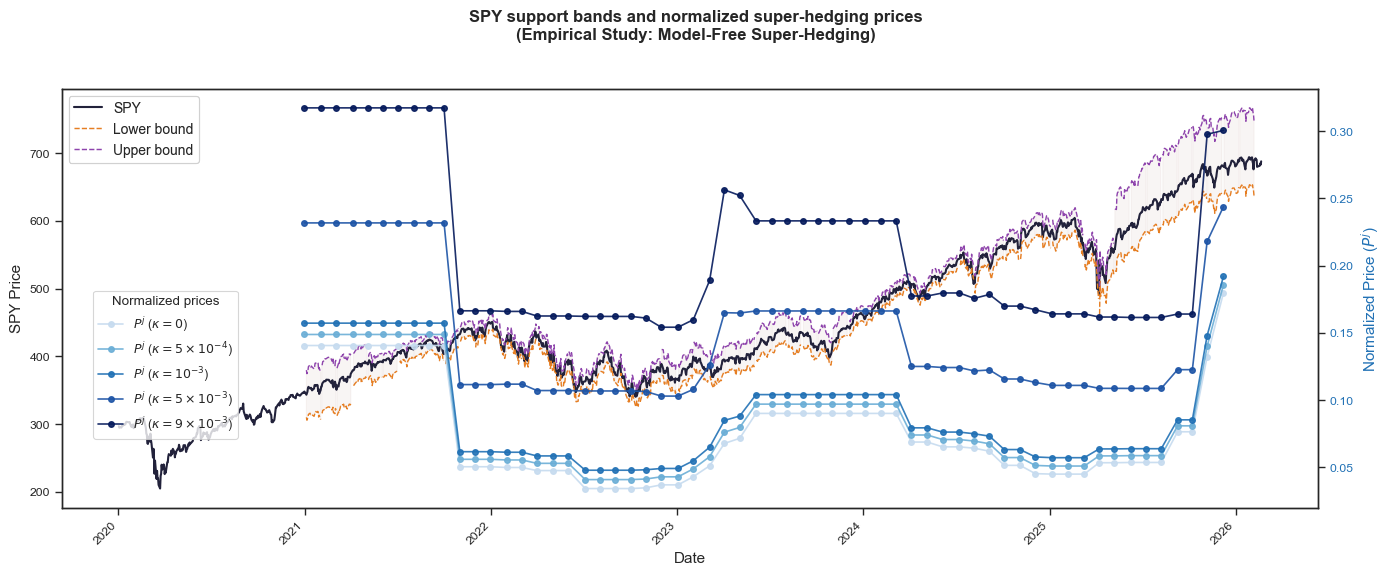

In [27]:
# ================================================================================
# Overlay Plot: SPY, Support Bands, and Normalized Price P^j
# ================================================================================
# Key features:
#   - Main axis: SPY price + dynamically calibrated support bands
#   - Secondary axis: Normalized super-hedging prices P^j for all kappa values
#   - Safe synchronization: period indices mapped to timestamps
#   - High-resolution outputs for publication
# ================================================================================

import matplotlib.dates as mdates

# Build a safe map from period index -> timestamp
period_start_map = {idx: close.index[idx_val] for idx, idx_val in enumerate(period_starts)}

# Define display labels and color palette for kappa values
pj_kappas_label = [r"$\kappa=0$", r"$\kappa=5\times10^{-4}$", r"$\kappa=10^{-3}$",
                   r"$\kappa=5\times10^{-3}$", r"$\kappa=9\times10^{-3}$"]
pj_display_labels = [f"$P^j$ ({k})" for k in pj_kappas_label]

# Color palette: gradient from light to dark blue for increasing kappa
color_palette = {
    pj_kappas_label[0]: "#C6DBEF",
    pj_kappas_label[1]: "#6BAED6",
    pj_kappas_label[2]: "#2171B5",
    pj_kappas_label[3]: "#1D54A6",
    pj_kappas_label[4]: "#051A5C"
}

# Create figure with adequate size for readability
fig, ax1 = plt.subplots(figsize=(14, 6))

# ---- Main Axis (ax1): SPY + Support Bands ----
ax1.plot(close.index, close.values, color="#22223B", linewidth=1.5, label="SPY")
ax1.plot(close.index, lower_full.values, color="#E67E22", linewidth=1.0, 
         linestyle="--", label="Lower bound")
ax1.plot(close.index, upper_full.values, color="#8E44AD", linewidth=1.0, 
         linestyle="--", label="Upper bound")
ax1.fill_between(close.index, lower_full.values, upper_full.values, 
                 color="#C9ADA7", alpha=0.12)
ax1.set_ylabel('SPY Price', fontsize=11)
ax1.set_xlabel('Date', fontsize=11)

# ---- Secondary Axis (ax2): Normalized Prices P^j ----
ax2 = ax1.twinx()
for kappa_label, display_label in zip(pj_kappas_label, pj_display_labels):
    # Filter data for this kappa value
    pj_mask = allm['kappa'] == kappa_label
    pj_df = allm.loc[pj_mask].copy()
    
    if pj_df.empty:
        continue  # Skip if no data for this kappa
    
    # Sort by period index for correct time ordering
    pj_df = pj_df.sort_values('i')
    
    # Keep only indices we can safely map to timestamps
    pj_df = pj_df[pj_df['i'].isin(period_start_map.keys())]
    
    if pj_df.empty:
        continue  # Skip if no valid indices after filtering
    
    # Convert period indices to actual timestamps
    pj_x = [period_start_map[int(ii)] for ii in pj_df['i'].values]
    pj_y = pj_df['Pj'].values
    
    # Plot P^j curve with markers and color from palette
    ax2.plot(pj_x, pj_y, color=color_palette[kappa_label], marker='o', 
             linestyle='-', label=display_label, alpha=0.9, markersize=4)

ax2.set_ylabel('Normalized Price ($P^j$)', color='#2171B5', fontsize=11)
ax2.tick_params(axis='y', labelcolor='#2171B5')

# ---- Format axes ----
# X-axis: automatic date locator with concise formatting
ax1.xaxis.set_major_locator(mdates.AutoDateLocator())
ax1.xaxis.set_major_formatter(mdates.ConciseDateFormatter(mdates.AutoDateLocator()))
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha='right')

# ---- Legends ----
# Keep calibration legend on ax1 (upper left)
handles1, labels1 = ax1.get_legend_handles_labels()
legend1 = ax1.legend(handles1, labels1, loc='upper left', frameon=True, fontsize=10)
ax1.add_artist(legend1)

# Add P^j legend on ax2 (lower left, positioned to avoid overlap)
handles2, labels2 = ax2.get_legend_handles_labels()
legend2 = ax2.legend(handles2, labels2, loc='lower left', 
                     bbox_to_anchor=(0.02, 0.15), frameon=True, 
                     title='Normalized prices', fontsize=9)

# ---- Title ----
plt.suptitle(
    'SPY support bands and normalized super-hedging prices\n' + 
    '(Empirical Study: Model-Free Super-Hedging)',
    fontsize=12, fontweight='bold'
)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])


plt.show()

---

## 5. Grid Study: Detailed Cost Impact Analysis

To understand the fine structure of transaction cost impacts, we analyze a dense grid of $\kappa$ values from 0 to 0.01 (100+ points) for a representative period.

**Mathematical relationships:**
- $P(\kappa) = V_0^j / S_0^j$: normalized super-hedging price
- $I(\kappa) = \frac{P(\kappa) - P(0)}{\kappa}$: marginal cost impact per unit of transaction cost rate

**Key findings:**
- $P(\kappa)$ exhibits smooth, strictly increasing, convex growth
- Price nearly triples as $\kappa$ increases from 0 to 0.01
- Cost impact reveals the elasticity of hedging cost to transaction rates

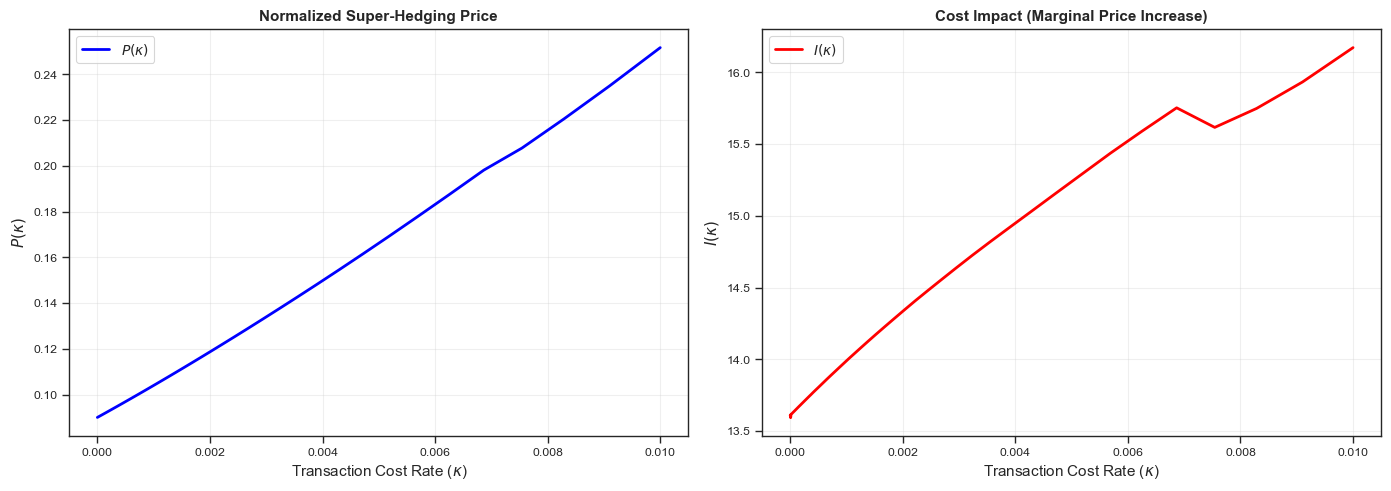

✓ Grid study analysis complete
  - κ range: [0.0000, 0.0100]
  - P(0) = 0.090026
  - P(0.01) ≈ 0.251746 (≈ 2.80× P(0))


In [28]:
# ================================================================================
# Grid Study: Cost Impact Analysis for Continuous κ Range
# ================================================================================
# Load grid test results and analyze cost impact over continuous κ ∈ [0, 0.01]

# Load the grid study results
df_grid = pd.read_csv("results_kappa_grid_test.csv")

# Clean columns (handles [value] format in CSV)
cols_to_clean = ['V0', 'VT', 'ST', 'S0', 'K_payoff', 'payoff']
for col in cols_to_clean:
    df_grid[col] = df_grid[col].astype(str).str.replace(r'[\[\]]', '', regex=True).astype(float)

# Compute normalized price P(kappa)
df_grid['P_kappa'] = df_grid['V0'] / df_grid['S0']

# Reference frictionless price P(0)
p_0 = df_grid.loc[df_grid['kappa'] == 0, 'P_kappa'].values[0]

# Cost Impact I(kappa) = (P(kappa) - P(0)) / kappa (avoid division by zero)
df_grid['I_kappa'] = np.where(df_grid['kappa'] > 0, (df_grid['P_kappa'] - p_0) / df_grid['kappa'], np.nan)

# Relative super-hedging difference epsilon = (VT - payoff) / ST
df_grid['epsilon'] = (df_grid['VT'] - df_grid['payoff']) / df_grid['ST']

# ---- Plot 1: Normalized Price P(kappa) ----
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Normalized Price
axes[0].plot(df_grid['kappa'], df_grid['P_kappa'], color='blue', linewidth=2, label=r'$P(\kappa)$')
axes[0].set_xlabel(r'Transaction Cost Rate ($\kappa$)', fontsize=11)
axes[0].set_ylabel(r'$P(\kappa)$', fontsize=11)
axes[0].grid(True, alpha=0.3)
axes[0].legend(fontsize=10)
axes[0].set_title('Normalized Super-Hedging Price', fontsize=11, fontweight='bold')

# Cost Impact
axes[1].plot(df_grid['kappa'], df_grid['I_kappa'], color='red', linewidth=2, label=r'$I(\kappa)$')
axes[1].set_xlabel(r'Transaction Cost Rate ($\kappa$)', fontsize=11)
axes[1].set_ylabel(r'$I(\kappa)$', fontsize=11)
axes[1].grid(True, alpha=0.3)
axes[1].legend(fontsize=10)
axes[1].set_title('Cost Impact (Marginal Price Increase)', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('fig_grid_study_kappa.pdf', bbox_inches='tight', dpi=300)
plt.savefig('fig_grid_study_kappa.png', bbox_inches='tight', dpi=200)
plt.show()

print("✓ Grid study analysis complete")
print(f"  - κ range: [{df_grid['kappa'].min():.4f}, {df_grid['kappa'].max():.4f}]")
print(f"  - P(0) = {p_0:.6f}")
print(f"  - P(0.01) ≈ {df_grid.loc[df_grid['kappa'] < 0.011, 'P_kappa'].max():.6f} (≈ {df_grid.loc[df_grid['kappa'] < 0.011, 'P_kappa'].max()/p_0:.2f}× P(0))")


---

## 6. Summary & Key Findings

### Main Results from Empirical Analysis

1. **Support Band Calibration**: 
   - Upper & lower bounds are calibrated from rolling 252-day windows of returns
   - SPY stays within bands by construction, validating the model assumptions

2. **Relative Super-Hedging Error ($\epsilon^j$)**:
   - Always non-negative, confirming super-hedging constraint satisfaction
   - Mean values: 5% ($\kappa=0$), 6% ($\kappa=5\times10^{-4}$), 7% ($\kappa=10^{-3}$), 12% ($\kappa=5\times10^{-3}$)
   - Increases with $\kappa$ due to wider support bands under higher transaction costs

3. **Normalized Prices ($P^j(\kappa)$)**:
   - Strictly increasing and convex in $\kappa$
   - Shows the cost of transaction costs on option pricing

4. **Cost Impact ($I^j(\kappa)$)**:
   - Measures the elasticity of pricing to transaction rates
   - Provides insight into how transaction costs affect hedging requirements